<a href="https://colab.research.google.com/github/Vaibhav-Thalanki/Airbnb-Price-Modeling/blob/master/CS6140_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**IMPORTS**

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style("whitegrid")

**LOAD DATA**

In [35]:
train = pd.read_csv("train.csv")

**EDA**

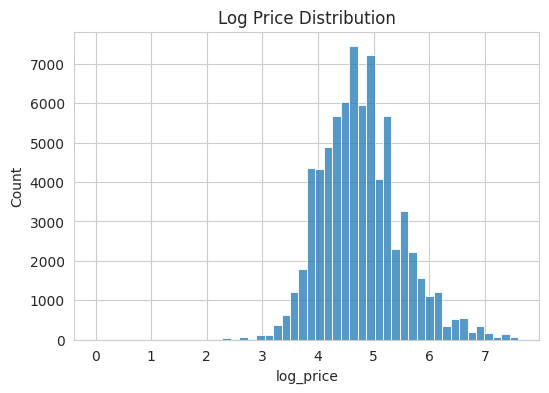

In [36]:
# Target Distribution
plt.figure(figsize=(6,4))
sns.histplot(train['log_price'], bins=50)
plt.title("Log Price Distribution")
plt.show()

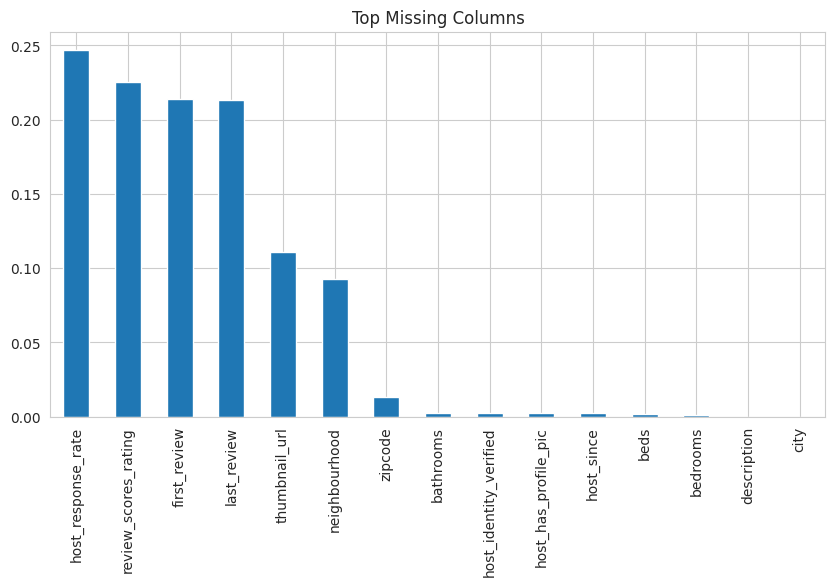

In [37]:
# Missing Values
missing = train.isnull().mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
missing.head(15).plot(kind='bar')
plt.title("Top Missing Columns")
plt.show()

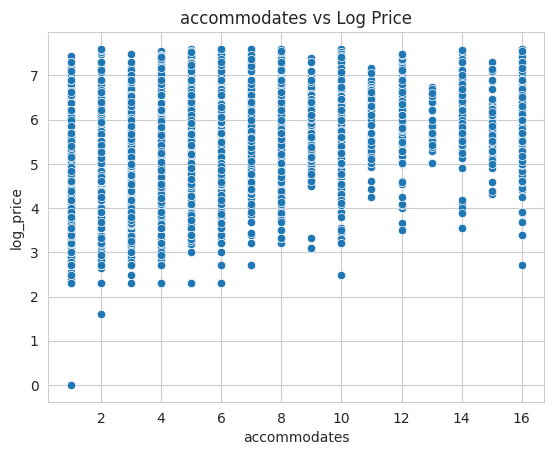

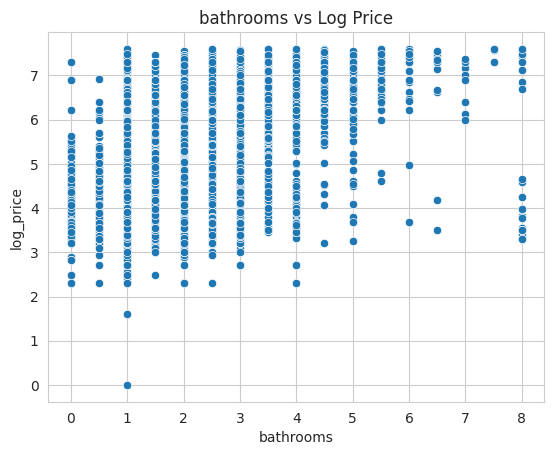

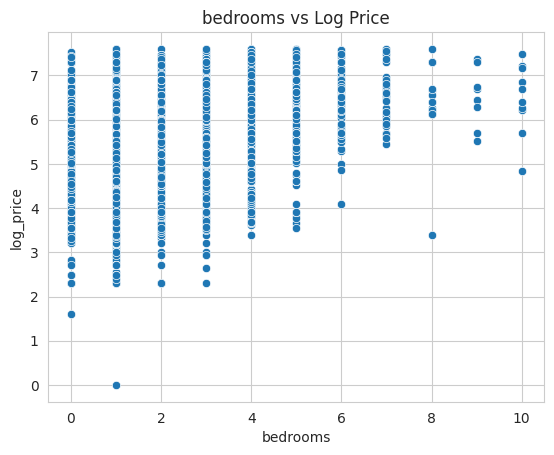

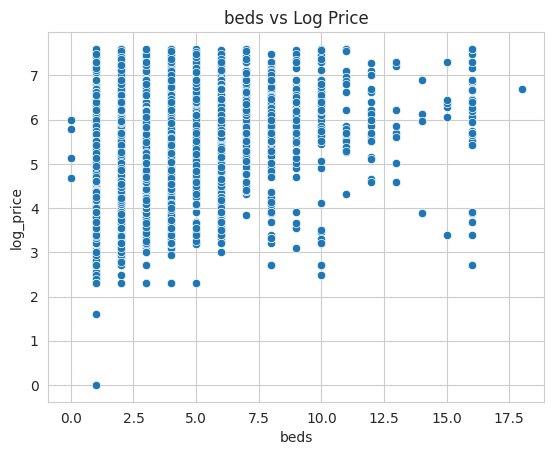

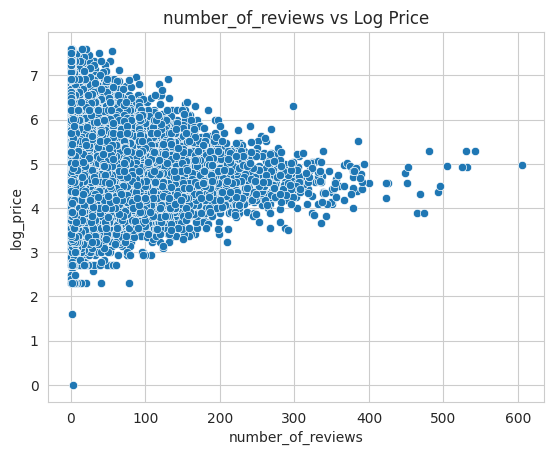

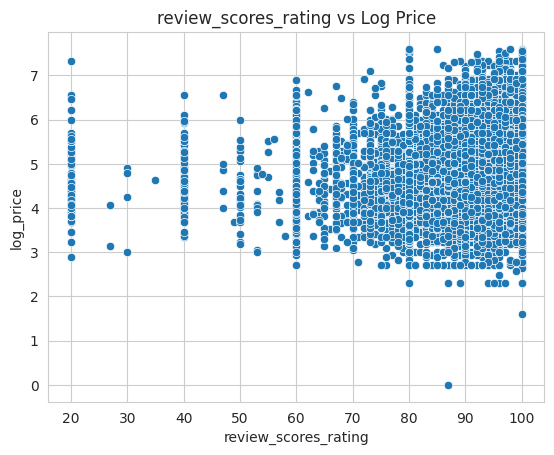

In [38]:
# Numerical Features
num_cols = [
    'accommodates', 'bathrooms', 'bedrooms',
    'beds', 'number_of_reviews', 'review_scores_rating'
]

for col in num_cols:
    plt.figure()
    sns.scatterplot(x=train[col], y=train['log_price'])
    plt.title(f"{col} vs Log Price")
    plt.show()

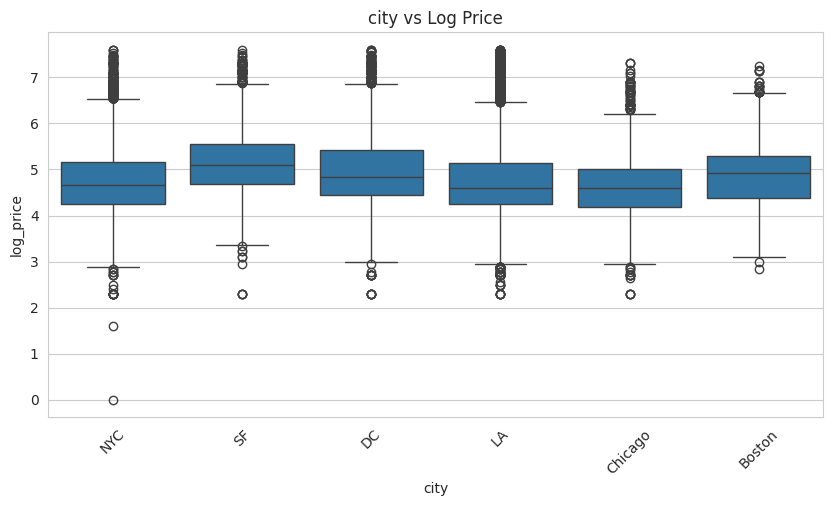

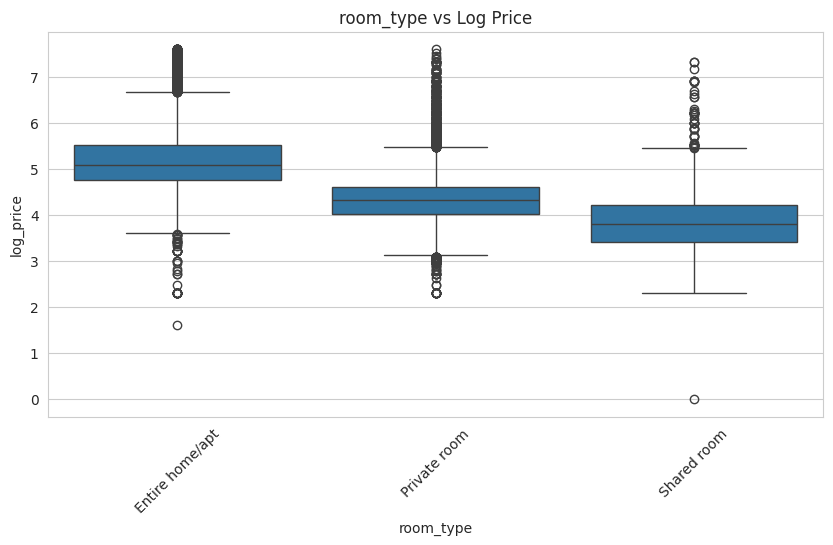

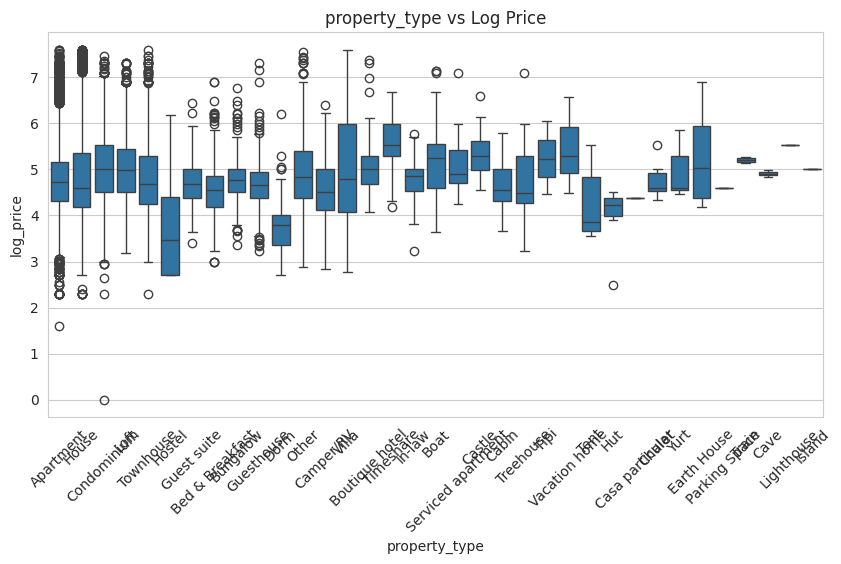

In [39]:
# Categorical Features
cat_cols = ['city', 'room_type', 'property_type']

for col in cat_cols:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=train[col], y=train['log_price'])
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Log Price")
    plt.show()

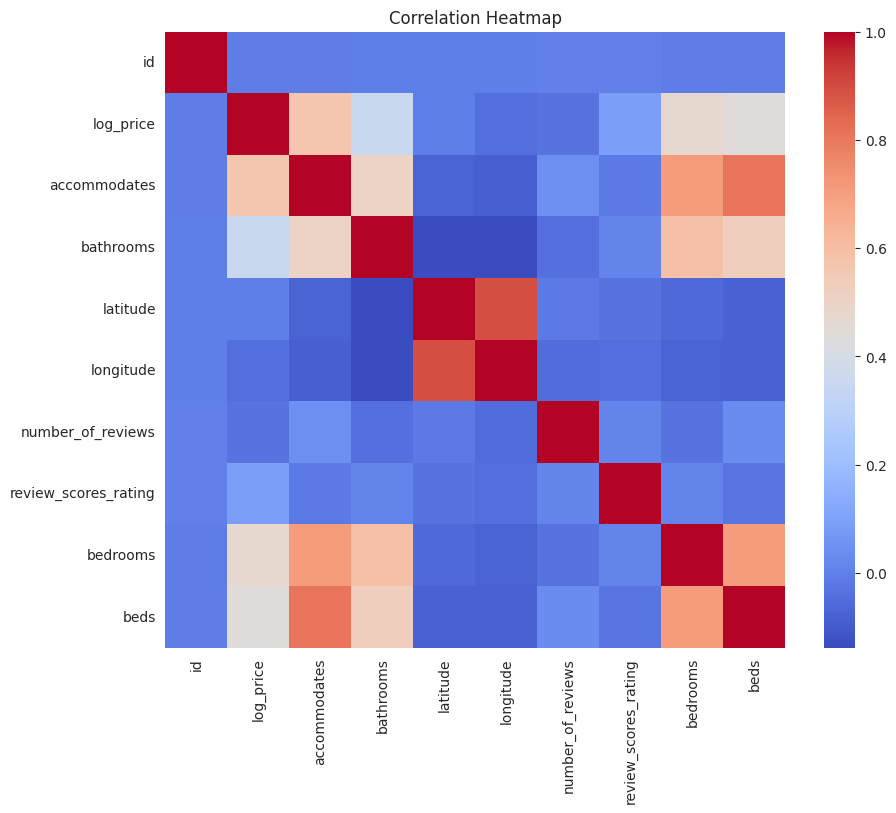

In [40]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
corr = train.select_dtypes(include=np.number).corr()
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


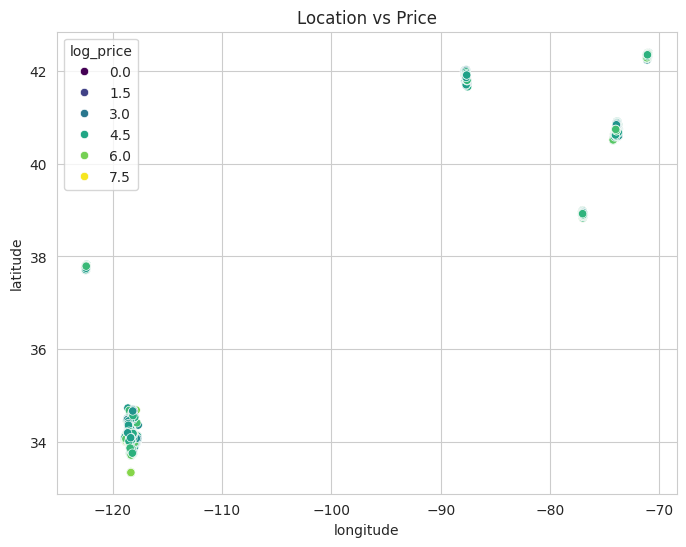

In [41]:
# Location Plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=train['longitude'],
    y=train['latitude'],
    hue=train['log_price'],
    palette='viridis'
)
plt.title("Location vs Price")
plt.show()

**PREPROCESSING**

In [42]:
# Drop useless columns
drop_cols = [
    'id', 'thumbnail_url', 'description', 'name',
    'amenities', 'first_review', 'last_review', 'host_since'
]
train = train.drop(columns=drop_cols, errors='ignore')

In [43]:
# Boolean columns
bool_cols = [
    'host_has_profile_pic',
    'host_identity_verified',
    'instant_bookable',
    'cleaning_fee'
]

for col in bool_cols:
    train[col] = train[col].map({'t': 1, 'f': 0})


In [44]:
# Clean percentage column
train['host_response_rate'] = train['host_response_rate'].str.replace('%', '')
train['host_response_rate'] = pd.to_numeric(train['host_response_rate'], errors='coerce')

In [45]:
# Fill missing values
num_cols = train.select_dtypes(include=np.number).columns
train[num_cols] = train[num_cols].fillna(train[num_cols].median())

cat_cols = train.select_dtypes(include='object').columns
for col in cat_cols:
    train[col] = train[col].fillna(train[col].mode()[0])

In [46]:
# One-hot encoding
train_encoded = pd.get_dummies(train, drop_first=True)
train_encoded = train_encoded.fillna(0)

**DEFINE FEATURES**

In [47]:
X = train_encoded.drop(['log_price'], axis=1)
y = train_encoded['log_price']

**TRAIN-TEST SPLIT**

In [48]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**SCALING**

In [49]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

**LINEAR REGRESSION**

In [50]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

**PREDICTIONS**

In [51]:
y_pred = model.predict(X_val)

**EVALUATION**

In [52]:
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

RMSE: 0.41653469767170953
MAE: 0.30208076018691216
R2: 0.6622690137724552


**FEATURE IMPORTANCE**

In [53]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("\nTop Positive Features:")
print(coefficients.head(10))

print("\nTop Negative Features:")
print(coefficients.tail(10))



Top Positive Features:
                             Feature  Coefficient
7                           latitude     0.314839
0                       accommodates     0.179092
11                          bedrooms     0.131055
666       neighbourhood_Williamsburg     0.070238
527   neighbourhood_Roosevelt Island     0.066012
1                          bathrooms     0.065839
891                  zipcode_11211.0     0.059486
753                    zipcode_10019     0.054849
1207                   zipcode_90291     0.054483
776                    zipcode_10036     0.051918

Top Negative Features:
                    Feature  Coefficient
101   neighbourhood_Bayside    -0.036373
784           zipcode_10044    -0.055288
48    room_type_Shared room    -0.149262
47   room_type_Private room    -0.244597
60                 city_NYC    -1.436131
58                  city_DC    -1.641407
57             city_Chicago    -4.118176
61                  city_SF   -15.852413
59                  city_LA   -23

**SAVE CLEAN DATA**

In [54]:
train_encoded.to_csv("cleaned_train.csv", index=False)